1. Membaca Data OBT (One Big Table)...
2. Pre-processing: Standarisasi Data...
3. Melatih Model K-Means Clustering (Membagi jadi 4 Segmen)...

--- 4. Profil Masing-Masing Segmen Pelanggan ---
         recency  frequency  monetary  jumlah_pelanggan
cluster                                                
0         127.82       1.00    134.37             50726
1         387.22       1.00    133.47             37443
2         219.96       2.11    289.68              2772
3         239.00       1.01   1161.33              2416


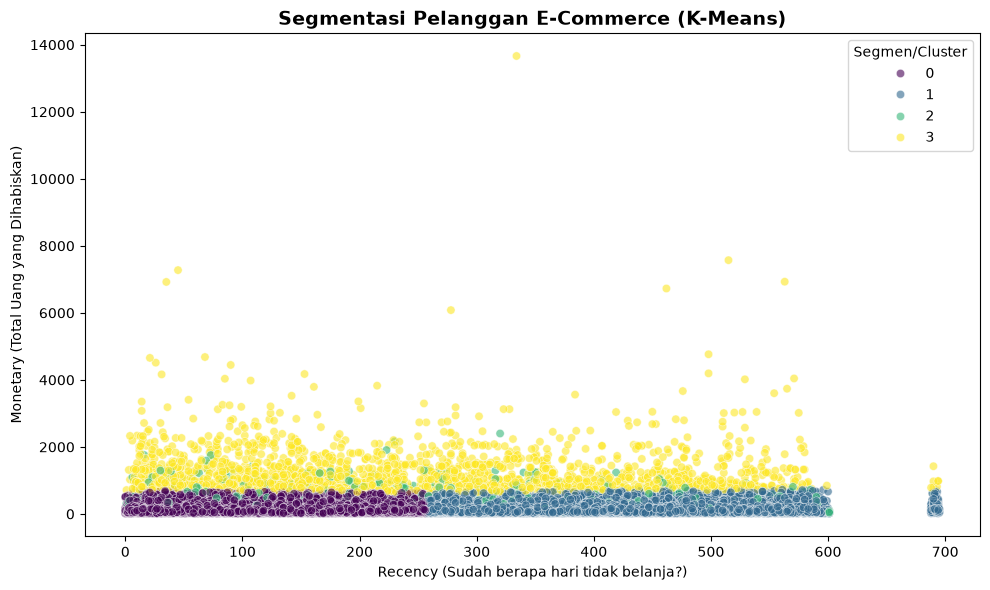

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("1. Membaca Data OBT (One Big Table)...")
df = pd.read_parquet('../data/processed/rfm_churn_data.parquet')

print("2. Pre-processing: Standarisasi Data...")
# 'Monetary' bisa ribuan, sedangkan 'Frequency' cuma satuan. 
# Ratakan skalanya pakai StandardScaler.
features = ['recency', 'frequency', 'monetary']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("3. Melatih Model K-Means Clustering (Membagi jadi 4 Segmen)...")
# AI membagi 93 ribu pelanggan menjadi 4 grup berdasarkan kemiripan karakternya
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\n--- 4. Profil Masing-Masing Segmen Pelanggan ---")
# Rata-rata Recency, Frequency, dan Monetary dari tiap grup
cluster_profile = df.groupby('cluster')[features].mean().round(2)
cluster_profile['jumlah_pelanggan'] = df['cluster'].value_counts()
print(cluster_profile)

# 5. Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='recency', 
    y='monetary', 
    hue='cluster', 
    palette='viridis', 
    alpha=0.6
)
plt.title('Segmentasi Pelanggan E-Commerce (K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Sudah berapa hari tidak belanja?)')
plt.ylabel('Monetary (Total Uang yang Dihabiskan)')
plt.legend(title='Segmen/Cluster')
plt.tight_layout()
plt.show()